In [2]:
import os
import sys
sys.path.append(os.path.abspath('..'))


# Import packages

In [3]:
from galaxy_classification.models.neural_network import GalaxyCNN
from galaxy_classification.data.loader import GalaxyDataLoader
from torch.utils.data import DataLoader
from galaxy_classification.training.train import GalaxyTrainerMultimodal
from galaxy_classification.data.dataset import GalaxyDatasetMultimodal
from galaxy_classification.models.neural_network import GalaxyMultimodalNet
from galaxy_classification.data.transformed_subset import TransformedSubsetMultimodal
import torch
from torchvision import transforms
from torch.utils.data import random_split

c:\Users\User\Desktop\Університет\4_курс\ДИПЛОМ\galaxy-classification\.galaxy_env\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


# Import dataset and split to test and train

In [4]:
tabular_features = ['ra', 'dec', 'redshift', 'pxscale', 'u', 'g', 'r', 'i', 'z_mag', 'z', 'zErr', 'velDisp',
       'snMedian', 'petroR50_r', 'petroR90_r',
       'q_r', 'u_r', 'fracDeV_r', 'flags', 'plate', 'mjd', 'fiberID']

In [5]:
dataset = GalaxyDatasetMultimodal("../data/galaxies_multimodal.h5", tabular_features)  

test_ratio = 0.25
test_size = int(len(dataset) * test_ratio)
train_size = len(dataset) - test_size


In [6]:
from torchvision import transforms
import torch

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(180),

    transforms.RandomResizedCrop(
        size=256,
        scale=(0.6, 1.0),   
        ratio=(0.9, 1.1)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
])


test_transforms = transforms.Compose([]) 


In [7]:
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [8]:
train_dataset = TransformedSubsetMultimodal(train_dataset, transform=train_transforms)
test_dataset = TransformedSubsetMultimodal(test_dataset, transform=test_transforms)

In [9]:
train_dataset

# Train MultiModal

In [10]:
trainer = GalaxyTrainerMultimodal(num_tabular_features=len(tabular_features))

In [11]:
image, tab, label = train_dataset.subset[0]

In [12]:
trainer.train(train_dataset, test_dataset, num_epochs=50, batch_size=64)

c:\Users\User\Desktop\Університет\4_курс\ДИПЛОМ\galaxy-classification\galaxy_classification\training\train.py:318: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == "cuda"))
Epoch 1:   0%|          | 0/103 [00:00<?, ?it/s]

c:\Users\User\Desktop\Університет\4_курс\ДИПЛОМ\galaxy-classification\.galaxy_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\User\Desktop\Університет\4_курс\ДИПЛОМ\galaxy-classification\galaxy_classification\training\train.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device.type == "cuda")):
Epoch 1:   2%|▏         | 2/103 [02:17<1:55:21, 68.53s/it]


KeyboardInterrupt: 

In [29]:
model = GalaxyCNN()
model.load_model("../models/best_0.8200.pth")

In [30]:
test_loader = DataLoader(
            test_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )


In [32]:
class_names = ["Disturbed / Merging", "Smooth", "Spiral", "Edge-on"]


🔥 FINAL METRICS
Accuracy:  0.8198
F1-score:  0.8038
Precision: 0.8012
Recall:    0.8165

📊 Classification Report:

                     precision    recall  f1-score   support

Disturbed / Merging       0.69      0.61      0.65       734
             Smooth       0.80      0.91      0.85      1229
             Spiral       0.91      0.77      0.83      1666
            Edge-on       0.80      0.97      0.88       805

           accuracy                           0.82      4434
          macro avg       0.80      0.82      0.80      4434
       weighted avg       0.82      0.82      0.82      4434



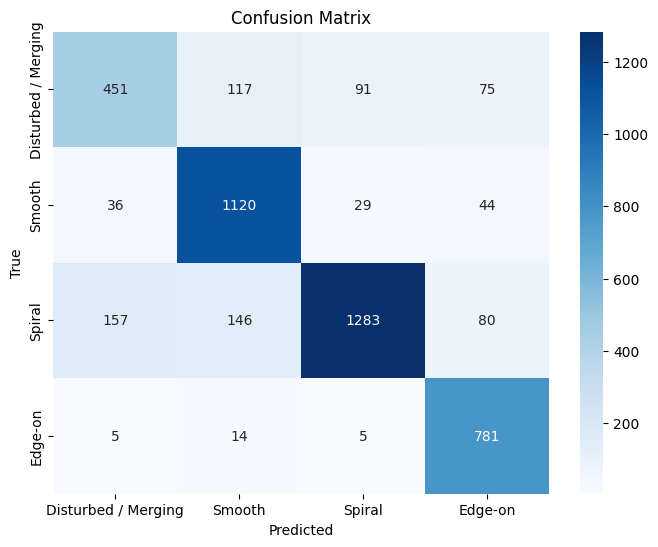

{'accuracy': 0.8198015336039693,
 'f1': 0.8037566905786332,
 'precision': 0.8011983969322202,
 'recall': 0.8165114509128607}

In [33]:
trainer.evaluate_metrics(model, test_loader, class_names)

In [34]:
trainer.plot_metrics()